# MNPS Job Classification Likelihood Scorer v6.0 - ERROR COST ANALYSIS

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yourusername/yourrepo/blob/main/MNPS_Job_Classification_Likelihood_Scorer_v6_Error_Cost_Analysis.ipynb)

## 🎯 Critical Improvements in v6.0

### Core Error Analysis Features:
1. **🔬 KSAC Similarity Analysis** - Measures classification accuracy by KSAC profile matching
2. **💰 Salary-Weighted Error Costs** - Calculates financial impact of misclassifications
3. **⏱️ Correction Time Estimation** - Predicts effort needed to fix errors
4. **🎭 Cross-Role Comparison** - Compares assigned role vs. alternative roles
5. **📊 Error Severity Scoring** - Quantifies how bad a misclassification is

### Error Cost Formula:
```
Error Cost = (KSAC Dissimilarity × Salary Factor × Correction Time)
           = (How wrong) × (Financial impact) × (Time to fix)
```

### Key Metrics:
- **KSAC Match Score**: 0-1 (1 = perfect match)
- **Error Severity**: 0-1 (0 = correct, 1 = completely wrong)
- **Cost Impact**: $0 - $50,000+ per misclassification
- **Correction Time**: 1-80 hours depending on severity

---

In [1]:
#@title 1️⃣ Setup Environment and Mount Drive { display-mode: "form" }

from google.colab import drive
import os
import datetime
import zipfile
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine, euclidean
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
print("🔗 Mounting Google Drive...")
drive.mount('/content/drive')

# Create directory structure
base_path = '/content/drive/MyDrive/MNPS_Likelihood_Analysis'
resources_path = os.path.join(base_path, 'Resources')
results_path = os.path.join(base_path, 'Results')
inputs_path = os.path.join(base_path, 'Inputs')

for path in [base_path, resources_path, results_path, inputs_path]:
    os.makedirs(path, exist_ok=True)

timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
run_results_path = os.path.join(results_path, f'Run_v6_{timestamp}')
os.makedirs(run_results_path, exist_ok=True)

print(f"✅ Environment ready! Results: {run_results_path}")

🔗 Mounting Google Drive...
Mounted at /content/drive
✅ Environment ready! Results: /content/drive/MyDrive/MNPS_Likelihood_Analysis/Results/Run_v6_20251121_204228


In [2]:
#@title 2️⃣ Configure Error Cost Parameters { display-mode: "form" }

# Error Analysis Parameters
KSAC_DISSIMILARITY_WEIGHT = 0.40  #@param {type:"slider", min:0.2, max:0.6, step:0.05}
SALARY_IMPACT_WEIGHT = 0.35  #@param {type:"slider", min:0.2, max:0.5, step:0.05}
CORRECTION_TIME_WEIGHT = 0.25  #@param {type:"slider", min:0.1, max:0.4, step:0.05}

# Severity Thresholds
CRITICAL_ERROR_THRESHOLD = 0.75  #@param {type:"slider", min:0.6, max:0.9, step:0.05}
MAJOR_ERROR_THRESHOLD = 0.50  #@param {type:"slider", min:0.4, max:0.7, step:0.05}
MINOR_ERROR_THRESHOLD = 0.25  #@param {type:"slider", min:0.1, max:0.4, step:0.05}

# Cost Multipliers
EXECUTIVE_SALARY_MULTIPLIER = 2.0  #@param {type:"number"}
MANAGEMENT_SALARY_MULTIPLIER = 1.5  #@param {type:"number"}
PROFESSIONAL_SALARY_MULTIPLIER = 1.0  #@param {type:"number"}

# Time to Correct Multipliers (hours)
BASE_CORRECTION_TIME = 8  #@param {type:"number"}
CRITICAL_TIME_MULTIPLIER = 10  #@param {type:"number"}
MAJOR_TIME_MULTIPLIER = 5  #@param {type:"number"}
MINOR_TIME_MULTIPLIER = 2  #@param {type:"number"}

# Human Baseline
HUMAN_BASELINE_MIN = 88
HUMAN_BASELINE_MAX = 94

print("📊 Error Cost Configuration:")
print(f"  Weights: KSAC={KSAC_DISSIMILARITY_WEIGHT}, Salary={SALARY_IMPACT_WEIGHT}, Time={CORRECTION_TIME_WEIGHT}")
print(f"  Severity: Critical>{CRITICAL_ERROR_THRESHOLD}, Major>{MAJOR_ERROR_THRESHOLD}, Minor>{MINOR_ERROR_THRESHOLD}")
print(f"  Correction Base: {BASE_CORRECTION_TIME} hours")

📊 Error Cost Configuration:
  Weights: KSAC=0.4, Salary=0.35, Time=0.25
  Severity: Critical>0.75, Major>0.5, Minor>0.25
  Correction Base: 8 hours


In [3]:
#@title 3️⃣ Upload Required Files { display-mode: "form" }

from google.colab import files

print("📤 Please upload the following files:")
print("1. Evaluation Resources.zip (MUST contain KSACs.csv, Salary_Data.csv, Time_to_Correct.csv)")
print("2. Job Descriptions CSV")
print("3. Classifications CSV\n")

uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\n📁 Processing: {filename}")

    if filename.endswith('.zip'):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('/content/temp_extract')
        for root, dirs, files_list in os.walk('/content/temp_extract'):
            for file in files_list:
                src = os.path.join(root, file)
                dst = os.path.join(resources_path, file)
                shutil.copy(src, dst)
        shutil.rmtree('/content/temp_extract')
        print(f"   ✅ Resources extracted")
    else:
        shutil.copy(filename, os.path.join(inputs_path, filename))
        print(f"   ✅ Copied to inputs")

print("\n✅ Files uploaded successfully!")

📤 Please upload the following files:
1. Evaluation Resources.zip (MUST contain KSACs.csv, Salary_Data.csv, Time_to_Correct.csv)
2. Job Descriptions CSV
3. Classifications CSV



Saving Evaluation Resources.zip to Evaluation Resources.zip
Saving Job_Classifications_Batch.csv to Job_Classifications_Batch.csv
Saving Sample JDs.csv to Sample JDs.csv

📁 Processing: Evaluation Resources.zip
   ✅ Resources extracted

📁 Processing: Job_Classifications_Batch.csv
   ✅ Copied to inputs

📁 Processing: Sample JDs.csv
   ✅ Copied to inputs

✅ Files uploaded successfully!


In [5]:
#@title 4️⃣ Load Data and Resources { display-mode: "form" }

# --- BEGIN: Moved function definitions to ensure they are available ---
def create_synthetic_ksac_profiles():
    """Create synthetic KSAC profiles if real data not available"""

    ksac_dimensions = [
        'Collaborates', 'Communicates_Effectively', 'Manages_Complexity',
        'Ensures_Accountability', 'Decision_Quality', 'Builds_Networks',
        'Plans_and_Aligns', 'Optimizes_Work_Processes', 'Develops_Talent',
        'Strategic_Mindset', 'Drives_Results', 'Customer_Focus',
        'Technical_Expertise', 'Innovation', 'Adaptability'
    ]

    # Define typical KSAC profiles for each role
    role_profiles = {
        'Manager': [0.9, 0.9, 0.8, 0.95, 0.85, 0.7, 0.9, 0.8, 0.9, 0.85, 0.9, 0.7, 0.6, 0.7, 0.8],
        'Coordinator': [0.85, 0.8, 0.7, 0.8, 0.7, 0.8, 0.85, 0.75, 0.6, 0.6, 0.75, 0.7, 0.5, 0.6, 0.75],
        'Analyst': [0.7, 0.75, 0.85, 0.8, 0.8, 0.6, 0.8, 0.85, 0.5, 0.7, 0.8, 0.65, 0.85, 0.75, 0.7],
        'Specialist': [0.75, 0.7, 0.75, 0.75, 0.75, 0.65, 0.7, 0.7, 0.6, 0.65, 0.75, 0.8, 0.9, 0.7, 0.7],
        'Teacher': [0.8, 0.85, 0.7, 0.8, 0.75, 0.7, 0.8, 0.7, 0.85, 0.6, 0.8, 0.9, 0.8, 0.7, 0.8],
        'Instructor': [0.75, 0.8, 0.65, 0.75, 0.7, 0.65, 0.75, 0.65, 0.8, 0.55, 0.75, 0.85, 0.75, 0.65, 0.75],
        'Technician': [0.6, 0.65, 0.7, 0.7, 0.65, 0.5, 0.65, 0.75, 0.4, 0.5, 0.7, 0.7, 0.95, 0.6, 0.7],
        'Coach': [0.85, 0.9, 0.75, 0.8, 0.8, 0.8, 0.8, 0.75, 0.95, 0.7, 0.85, 0.85, 0.7, 0.75, 0.8],
        'Counselor': [0.9, 0.95, 0.8, 0.85, 0.85, 0.85, 0.75, 0.7, 0.8, 0.65, 0.8, 0.95, 0.65, 0.7, 0.85],
        'Director': [0.85, 0.9, 0.9, 0.9, 0.9, 0.85, 0.95, 0.85, 0.85, 0.95, 0.95, 0.8, 0.7, 0.8, 0.85],
        'Assistant': [0.7, 0.7, 0.6, 0.65, 0.6, 0.6, 0.65, 0.65, 0.5, 0.5, 0.65, 0.7, 0.6, 0.5, 0.7],
        'Accountant': [0.65, 0.7, 0.75, 0.9, 0.75, 0.55, 0.8, 0.8, 0.4, 0.65, 0.8, 0.6, 0.85, 0.6, 0.65],
        'Liaison': [0.9, 0.95, 0.75, 0.75, 0.75, 0.95, 0.8, 0.7, 0.6, 0.7, 0.8, 0.85, 0.6, 0.7, 0.8]
    }

    # Convert to DataFrame
    ksac_df = pd.DataFrame(role_profiles, index=ksac_dimensions).T
    ksac_df.index.name = 'Role'
    ksac_df.reset_index(inplace=True)

    return ksac_df

def create_salary_estimates():
    """Create salary estimates if real data not available"""

    salary_data = {
        'Role': ['Manager', 'Coordinator', 'Analyst', 'Specialist', 'Teacher',
                 'Instructor', 'Technician', 'Coach', 'Counselor', 'Director',
                 'Assistant', 'Accountant', 'Liaison'],
        'Base_Salary': [85000, 65000, 70000, 75000, 55000,
                       50000, 60000, 65000, 70000, 110000,
                       45000, 68000, 72000],
        'Tier': ['Management', 'Professional', 'Professional', 'Professional', 'Professional',
                'Professional', 'Professional', 'Professional', 'Professional', 'Executive',
                'Support', 'Professional', 'Professional']
    }

    # Add subgroup variations
    expanded_data = []
    for _, row in pd.DataFrame(salary_data).iterrows():
        for subgroup in ['I', 'II', 'III']:
            multiplier = {'I': 0.85, 'II': 1.0, 'III': 1.2}[subgroup]
            expanded_row = row.copy()
            expanded_row['Role_Subgroup'] = f"{row['Role']}_{subgroup}"
            expanded_row['Adjusted_Salary'] = row['Base_Salary'] * multiplier
            expanded_data.append(expanded_row)

    return pd.DataFrame(expanded_data)
# --- END: Moved function definitions ---

print("📂 Loading all data files...\n")

# Load classifications
class_files = [f for f in os.listdir(inputs_path) if 'classification' in f.lower() or 'input' in f.lower()]
if class_files:
    classifications = pd.read_csv(os.path.join(inputs_path, class_files[0]))
    print(f"✅ Classifications: {len(classifications)} records")

# Load job descriptions
jd_files = [f for f in os.listdir(inputs_path) if 'jd' in f.lower() or 'job' in f.lower()]
if jd_files:
    job_descriptions = pd.read_csv(os.path.join(inputs_path, jd_files[0]))
    print(f"✅ Job Descriptions: {len(job_descriptions)} records")

# Load critical resource files
print("\n📚 Loading resource files...")
resources = {}

# Try to load KSACs
ksac_file = os.path.join(resources_path, 'KSACs.csv')
if os.path.exists(ksac_file):
    resources['ksacs'] = pd.read_csv(ksac_file)
    print(f"  ✅ KSACs: {len(resources['ksacs'])} profiles")
else:
    print("  ⚠️ KSACs.csv not found - creating synthetic KSAC profiles")
    # Create synthetic KSAC profiles if not available
    resources['ksacs'] = create_synthetic_ksac_profiles()

# Try to load salary data
salary_file = os.path.join(resources_path, 'Salary_Data.csv')
if os.path.exists(salary_file):
    resources['salary_data'] = pd.read_csv(salary_file)
    print(f"  ✅ Salary Data: {len(resources['salary_data'])} roles")
else:
    print("  ⚠️ Salary_Data.csv not found - using estimates")
    resources['salary_data'] = create_salary_estimates()

# Try to load time to correct
time_file = os.path.join(resources_path, 'Time_to_Correct.csv')
if os.path.exists(time_file):
    resources['time_to_correct'] = pd.read_csv(time_file)
    print(f"  ✅ Time to Correct: loaded")
else:
    print("  ⚠️ Time_to_Correct.csv not found - using calculations")
    resources['time_to_correct'] = None

# Merge data
merged_data = classifications.copy()
if 'job_descriptions' in locals() and 'source_row_index' in merged_data.columns:
    merged_data = merged_data.merge(
        job_descriptions,
        left_on='source_row_index',
        right_index=True,
        how='left',
        suffixes=('', '_jd')
    )

print(f"\n✅ Data loaded! Total records: {len(merged_data)}")


📂 Loading all data files...

✅ Classifications: 43 records
✅ Job Descriptions: 43 records

📚 Loading resource files...
  ⚠️ KSACs.csv not found - creating synthetic KSAC profiles
  ✅ Salary Data: 68 roles
  ✅ Time to Correct: loaded

✅ Data loaded! Total records: 43


In [6]:
#@title 5️⃣ KSAC Similarity and Error Analysis Functions { display-mode: "form" }

def create_synthetic_ksac_profiles():
    """Create synthetic KSAC profiles if real data not available"""

    ksac_dimensions = [
        'Collaborates', 'Communicates_Effectively', 'Manages_Complexity',
        'Ensures_Accountability', 'Decision_Quality', 'Builds_Networks',
        'Plans_and_Aligns', 'Optimizes_Work_Processes', 'Develops_Talent',
        'Strategic_Mindset', 'Drives_Results', 'Customer_Focus',
        'Technical_Expertise', 'Innovation', 'Adaptability'
    ]

    # Define typical KSAC profiles for each role
    role_profiles = {
        'Manager': [0.9, 0.9, 0.8, 0.95, 0.85, 0.7, 0.9, 0.8, 0.9, 0.85, 0.9, 0.7, 0.6, 0.7, 0.8],
        'Coordinator': [0.85, 0.8, 0.7, 0.8, 0.7, 0.8, 0.85, 0.75, 0.6, 0.6, 0.75, 0.7, 0.5, 0.6, 0.75],
        'Analyst': [0.7, 0.75, 0.85, 0.8, 0.8, 0.6, 0.8, 0.85, 0.5, 0.7, 0.8, 0.65, 0.85, 0.75, 0.7],
        'Specialist': [0.75, 0.7, 0.75, 0.75, 0.75, 0.65, 0.7, 0.7, 0.6, 0.65, 0.75, 0.8, 0.9, 0.7, 0.7],
        'Teacher': [0.8, 0.85, 0.7, 0.8, 0.75, 0.7, 0.8, 0.7, 0.85, 0.6, 0.8, 0.9, 0.8, 0.7, 0.8],
        'Instructor': [0.75, 0.8, 0.65, 0.75, 0.7, 0.65, 0.75, 0.65, 0.8, 0.55, 0.75, 0.85, 0.75, 0.65, 0.75],
        'Technician': [0.6, 0.65, 0.7, 0.7, 0.65, 0.5, 0.65, 0.75, 0.4, 0.5, 0.7, 0.7, 0.95, 0.6, 0.7],
        'Coach': [0.85, 0.9, 0.75, 0.8, 0.8, 0.8, 0.8, 0.75, 0.95, 0.7, 0.85, 0.85, 0.7, 0.75, 0.8],
        'Counselor': [0.9, 0.95, 0.8, 0.85, 0.85, 0.85, 0.75, 0.7, 0.8, 0.65, 0.8, 0.95, 0.65, 0.7, 0.85],
        'Director': [0.85, 0.9, 0.9, 0.9, 0.9, 0.85, 0.95, 0.85, 0.85, 0.95, 0.95, 0.8, 0.7, 0.8, 0.85],
        'Assistant': [0.7, 0.7, 0.6, 0.65, 0.6, 0.6, 0.65, 0.65, 0.5, 0.5, 0.65, 0.7, 0.6, 0.5, 0.7],
        'Accountant': [0.65, 0.7, 0.75, 0.9, 0.75, 0.55, 0.8, 0.8, 0.4, 0.65, 0.8, 0.6, 0.85, 0.6, 0.65],
        'Liaison': [0.9, 0.95, 0.75, 0.75, 0.75, 0.95, 0.8, 0.7, 0.6, 0.7, 0.8, 0.85, 0.6, 0.7, 0.8]
    }

    # Convert to DataFrame
    ksac_df = pd.DataFrame(role_profiles, index=ksac_dimensions).T
    ksac_df.index.name = 'Role'
    ksac_df.reset_index(inplace=True)

    return ksac_df


def calculate_ksac_similarity(role1, role2, ksac_profiles):
    """
    Calculate similarity between two roles based on KSAC profiles.
    Returns similarity score (0-1, where 1 = identical)
    """
    if role1 not in ksac_profiles['Role'].values or role2 not in ksac_profiles['Role'].values:
        # If role not found, return moderate similarity
        return 0.5

    # Get KSAC vectors
    profile1 = ksac_profiles[ksac_profiles['Role'] == role1].iloc[:, 1:].values.flatten()
    profile2 = ksac_profiles[ksac_profiles['Role'] == role2].iloc[:, 1:].values.flatten()

    # Calculate cosine similarity
    similarity = cosine_similarity([profile1], [profile2])[0][0]

    return similarity


def calculate_error_severity(assigned_role, correct_role, ksac_profiles):
    """
    Calculate how severe a misclassification error is.
    Returns severity score (0-1, where 0 = correct, 1 = completely wrong)
    """
    if assigned_role == correct_role:
        return 0.0

    similarity = calculate_ksac_similarity(assigned_role, correct_role, ksac_profiles)
    severity = 1.0 - similarity

    return severity


def find_closest_alternative_roles(assigned_role, ksac_profiles, top_n=3):
    """
    Find the most similar alternative roles based on KSAC profiles.
    """
    if assigned_role not in ksac_profiles['Role'].values:
        return []

    similarities = []
    for role in ksac_profiles['Role'].values:
        if role != assigned_role:
            sim = calculate_ksac_similarity(assigned_role, role, ksac_profiles)
            similarities.append((role, sim))

    # Sort by similarity and return top N
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]


def calculate_dissimilarity_to_worst_match(assigned_role, ksac_profiles):
    """
    Calculate dissimilarity to the worst matching role.
    Used to understand if this is the worst possible classification.
    """
    if assigned_role not in ksac_profiles['Role'].values:
        return 0.5

    min_similarity = 1.0
    worst_role = None

    for role in ksac_profiles['Role'].values:
        if role != assigned_role:
            sim = calculate_ksac_similarity(assigned_role, role, ksac_profiles)
            if sim < min_similarity:
                min_similarity = sim
                worst_role = role

    dissimilarity = 1.0 - min_similarity
    return dissimilarity, worst_role

print("✅ KSAC analysis functions loaded")

✅ KSAC analysis functions loaded


In [7]:
#@title 6️⃣ Salary-Weighted Error Cost Functions { display-mode: "form" }

def create_salary_estimates():
    """Create salary estimates if real data not available"""

    salary_data = {
        'Role': ['Manager', 'Coordinator', 'Analyst', 'Specialist', 'Teacher',
                 'Instructor', 'Technician', 'Coach', 'Counselor', 'Director',
                 'Assistant', 'Accountant', 'Liaison'],
        'Base_Salary': [85000, 65000, 70000, 75000, 55000,
                       50000, 60000, 65000, 70000, 110000,
                       45000, 68000, 72000],
        'Tier': ['Management', 'Professional', 'Professional', 'Professional', 'Professional',
                'Professional', 'Professional', 'Professional', 'Professional', 'Executive',
                'Support', 'Professional', 'Professional']
    }

    # Add subgroup variations
    expanded_data = []
    for _, row in pd.DataFrame(salary_data).iterrows():
        for subgroup in ['I', 'II', 'III']:
            multiplier = {'I': 0.85, 'II': 1.0, 'III': 1.2}[subgroup]
            expanded_row = row.copy()
            expanded_row['Role_Subgroup'] = f"{row['Role']}_{subgroup}"
            expanded_row['Adjusted_Salary'] = row['Base_Salary'] * multiplier
            expanded_data.append(expanded_row)

    return pd.DataFrame(expanded_data)


def get_salary_for_role(role, subgroup, salary_data):
    """
    Get salary for a specific role and subgroup.
    """
    if salary_data is None or salary_data.empty:
        # Default estimates
        base_salaries = {
            'Director': 110000, 'Manager': 85000, 'Coordinator': 65000,
            'Analyst': 70000, 'Specialist': 75000, 'Teacher': 55000,
            'Coach': 65000, 'Counselor': 70000, 'Technician': 60000,
            'Instructor': 50000, 'Assistant': 45000, 'Accountant': 68000
        }
        base = base_salaries.get(role, 60000)

        # Apply subgroup multiplier
        if subgroup == 'III':
            return base * 1.2
        elif subgroup == 'II':
            return base * 1.0
        else:  # I or missing
            return base * 0.85

    # Try to find in salary data
    role_subgroup = f"{role}_{subgroup}" if subgroup else role

    if 'Role_Subgroup' in salary_data.columns:
        match = salary_data[salary_data['Role_Subgroup'] == role_subgroup]
        if not match.empty:
            return match.iloc[0]['Adjusted_Salary']

    if 'Role' in salary_data.columns:
        match = salary_data[salary_data['Role'] == role]
        if not match.empty:
            base = match.iloc[0].get('Base_Salary', 60000)
            if subgroup == 'III':
                return base * 1.2
            elif subgroup == 'II':
                return base * 1.0
            else:
                return base * 0.85

    return 60000  # Default


def calculate_salary_weighted_error_cost(assigned_role, assigned_subgroup,
                                         error_severity, salary_data):
    """
    Calculate the financial cost of a misclassification error.
    Cost = Base Salary × Error Severity × Tier Multiplier
    """
    salary = get_salary_for_role(assigned_role, assigned_subgroup, salary_data)

    # Determine tier multiplier
    if salary >= 100000:
        tier_multiplier = EXECUTIVE_SALARY_MULTIPLIER
    elif salary >= 70000:
        tier_multiplier = MANAGEMENT_SALARY_MULTIPLIER
    else:
        tier_multiplier = PROFESSIONAL_SALARY_MULTIPLIER

    # Calculate annual cost impact
    # Assumption: Error severity affects productivity/effectiveness
    productivity_loss = error_severity * 0.25  # 25% max productivity loss
    annual_cost = salary * productivity_loss * tier_multiplier

    return annual_cost

print("✅ Salary cost calculation functions loaded")

✅ Salary cost calculation functions loaded


In [8]:
#@title 7️⃣ Correction Time Estimation Functions { display-mode: "form" }

def estimate_correction_time(error_severity, role_complexity):
    """
    Estimate hours needed to correct a misclassification.
    Based on error severity and role complexity.
    """

    # Role complexity factors
    complexity_factors = {
        'Director': 2.0,
        'Manager': 1.8,
        'Specialist': 1.5,
        'Analyst': 1.4,
        'Counselor': 1.4,
        'Coach': 1.3,
        'Teacher': 1.3,
        'Coordinator': 1.2,
        'Accountant': 1.2,
        'Technician': 1.1,
        'Instructor': 1.0,
        'Assistant': 0.8,
        'Liaison': 1.3
    }

    complexity = complexity_factors.get(role_complexity, 1.0)

    # Calculate base correction time
    if error_severity >= CRITICAL_ERROR_THRESHOLD:
        base_time = BASE_CORRECTION_TIME * CRITICAL_TIME_MULTIPLIER
    elif error_severity >= MAJOR_ERROR_THRESHOLD:
        base_time = BASE_CORRECTION_TIME * MAJOR_TIME_MULTIPLIER
    elif error_severity >= MINOR_ERROR_THRESHOLD:
        base_time = BASE_CORRECTION_TIME * MINOR_TIME_MULTIPLIER
    else:
        base_time = BASE_CORRECTION_TIME

    # Apply complexity factor
    total_time = base_time * complexity

    # Add administrative overhead (meetings, documentation, approvals)
    admin_overhead = total_time * 0.25

    return total_time + admin_overhead


def categorize_error_severity(severity_score):
    """
    Categorize error severity into levels.
    """
    if severity_score >= CRITICAL_ERROR_THRESHOLD:
        return "Critical", "Complete reclassification needed"
    elif severity_score >= MAJOR_ERROR_THRESHOLD:
        return "Major", "Significant adjustments required"
    elif severity_score >= MINOR_ERROR_THRESHOLD:
        return "Minor", "Small corrections needed"
    else:
        return "Minimal", "Likely correct or very close"

print("✅ Correction time estimation functions loaded")

✅ Correction time estimation functions loaded


In [9]:
#@title 8️⃣ Comprehensive Error Cost Analysis { display-mode: "form" }

def perform_comprehensive_error_analysis(row, ksac_profiles, salary_data):
    """
    Perform complete error cost analysis for a single classification.
    Returns detailed metrics including KSAC similarity, cost impact, and correction time.
    """

    assigned_role = row.get('major_role_group', '')
    assigned_subgroup = row.get('minor_sub_group', '')
    job_title = row.get('job_title_original', '')
    justification = str(row.get('grouping_justification', ''))

    # 1. Find closest alternative roles
    alternatives = find_closest_alternative_roles(assigned_role, ksac_profiles, top_n=3)

    # 2. Calculate best and worst case similarities
    if alternatives:
        best_alternative = alternatives[0][0]
        best_similarity = alternatives[0][1]
        worst_dissimilarity, worst_role = calculate_dissimilarity_to_worst_match(assigned_role, ksac_profiles)
    else:
        best_alternative = "Unknown"
        best_similarity = 0.5
        worst_dissimilarity = 0.5
        worst_role = "Unknown"

    # 3. Calculate error severity (assume best alternative might be correct)
    error_severity = calculate_error_severity(assigned_role, best_alternative, ksac_profiles)

    # 4. Adjust severity based on justification quality
    if len(justification) > 500 and "aligns with" in justification.lower():
        error_severity *= 0.8  # Good justification reduces severity
    elif len(justification) < 200:
        error_severity *= 1.2  # Poor justification increases severity

    error_severity = min(1.0, error_severity)  # Cap at 1.0

    # 5. Calculate salary-weighted cost
    salary_cost = calculate_salary_weighted_error_cost(
        assigned_role, assigned_subgroup, error_severity, salary_data
    )

    # 6. Estimate correction time
    correction_time = estimate_correction_time(error_severity, assigned_role)

    # 7. Calculate total error cost score
    # Normalize components
    norm_severity = error_severity  # Already 0-1
    norm_salary = min(1.0, salary_cost / 50000)  # Normalize to $50k max
    norm_time = min(1.0, correction_time / 80)  # Normalize to 80 hours max

    # Apply weights
    total_error_cost = (
        norm_severity * KSAC_DISSIMILARITY_WEIGHT +
        norm_salary * SALARY_IMPACT_WEIGHT +
        norm_time * CORRECTION_TIME_WEIGHT
    )

    # 8. Categorize severity
    severity_category, severity_description = categorize_error_severity(error_severity)

    # 9. Generate recommendations
    recommendations = []
    if error_severity > MAJOR_ERROR_THRESHOLD:
        recommendations.append(f"Consider reclassifying to {best_alternative}")
    if best_similarity > 0.85:
        recommendations.append(f"{best_alternative} is very similar (similarity: {best_similarity:.2f})")
    if correction_time > 40:
        recommendations.append("High correction effort - prioritize review")
    if salary_cost > 20000:
        recommendations.append(f"High financial impact: ${salary_cost:,.0f}/year")

    return {
        'ksac_best_alternative': best_alternative,
        'ksac_best_similarity': best_similarity,
        'ksac_worst_role': worst_role,
        'ksac_worst_dissimilarity': worst_dissimilarity,
        'error_severity': error_severity,
        'severity_category': severity_category,
        'severity_description': severity_description,
        'salary_cost_annual': salary_cost,
        'correction_time_hours': correction_time,
        'total_error_cost_score': total_error_cost,
        'alternatives': ', '.join([f"{r[0]}({r[1]:.2f})" for r in alternatives]),
        'recommendations': '; '.join(recommendations) if recommendations else 'Classification appears appropriate'
    }


def calculate_likelihood_from_error_cost(error_cost_score):
    """
    Convert error cost score to likelihood score (0-5).
    Lower error cost = higher likelihood of being correct.
    """
    # Invert the error cost (high error = low likelihood)
    quality_score = 1.0 - error_cost_score

    # Map to 0-5 scale with human baseline at 4.0-4.75
    if quality_score >= 0.95:  # Nearly perfect
        return 4.75 + (quality_score - 0.95) * 5.0
    elif quality_score >= 0.88:  # Human baseline minimum
        return 4.0 + (quality_score - 0.88) * 10.71
    elif quality_score >= 0.75:  # Below human but good
        return 3.5 + (quality_score - 0.75) * 3.85
    elif quality_score >= 0.50:  # Questionable
        return 2.0 + (quality_score - 0.50) * 6.0
    elif quality_score >= 0.25:  # Poor
        return 1.0 + (quality_score - 0.25) * 4.0
    else:  # Critical
        return quality_score * 4.0

print("✅ Comprehensive error analysis engine ready")

✅ Comprehensive error analysis engine ready


In [10]:
#@title 9️⃣ Process All Records with Error Cost Analysis { display-mode: "form" }

print("🔄 Processing all records with error cost analysis...\n")

# Initialize results
results = []

# Process each record
for idx, row in merged_data.iterrows():
    # Perform comprehensive error analysis
    error_analysis = perform_comprehensive_error_analysis(
        row, resources['ksacs'], resources.get('salary_data')
    )

    # Calculate likelihood from error cost
    likelihood_score = calculate_likelihood_from_error_cost(
        error_analysis['total_error_cost_score']
    )

    # Calculate accuracy equivalent
    if likelihood_score >= 4.0:
        accuracy = HUMAN_BASELINE_MIN + (likelihood_score - 4.0) * 12
    else:
        accuracy = 75 + (likelihood_score - 3.0) * 13

    # Determine performance category
    if likelihood_score >= 4.75:
        category = "Superhuman"
    elif likelihood_score >= 4.5:
        category = "Excellent"
    elif likelihood_score >= 4.0:
        category = "Human-level"
    elif likelihood_score >= 3.0:
        category = "Below Human"
    elif likelihood_score >= 2.0:
        category = "Poor"
    else:
        category = "Critical"

    # Compile results
    result = {
        'record_id': idx,
        'job_title': row.get('job_title_original', ''),
        'classification': row.get('major_role_group', ''),
        'sub_group': row.get('minor_sub_group', ''),
        'likelihood_score': likelihood_score,
        'accuracy_equivalent': accuracy,
        'performance_category': category,
        **error_analysis
    }
    results.append(result)

# Create results DataFrame
results_df = pd.DataFrame(results)

# Display summary
print("📊 Processing Complete!\n")
print(f"Total Records: {len(results_df)}")
print(f"\nError Severity Distribution:")
for category in ['Critical', 'Major', 'Minor', 'Minimal']:
    count = len(results_df[results_df['severity_category'] == category])
    print(f"  {category}: {count} ({count/len(results_df)*100:.1f}%)")

print(f"\nFinancial Impact:")
print(f"  Total Annual Cost: ${results_df['salary_cost_annual'].sum():,.0f}")
print(f"  Average Cost per Error: ${results_df['salary_cost_annual'].mean():,.0f}")
print(f"\nCorrection Effort:")
print(f"  Total Hours Needed: {results_df['correction_time_hours'].sum():,.0f}")
print(f"  Average Hours per Case: {results_df['correction_time_hours'].mean():.1f}")

# Show top errors
print("\n🚨 Top 5 Most Costly Errors:")
top_errors = results_df.nlargest(5, 'total_error_cost_score')[['job_title', 'classification', 'severity_category', 'salary_cost_annual', 'correction_time_hours']]
for _, error in top_errors.iterrows():
    print(f"  • {error['job_title']} → {error['classification']}: {error['severity_category']} (${error['salary_cost_annual']:,.0f}, {error['correction_time_hours']:.1f}h)")

🔄 Processing all records with error cost analysis...

📊 Processing Complete!

Total Records: 43

Error Severity Distribution:
  Critical: 0 (0.0%)
  Major: 0 (0.0%)
  Minor: 11 (25.6%)
  Minimal: 32 (74.4%)

Financial Impact:
  Total Annual Cost: $67,265
  Average Cost per Error: $1,564

Correction Effort:
  Total Hours Needed: 635
  Average Hours per Case: 14.8

🚨 Top 5 Most Costly Errors:
  • Translator School Based Parent Outreach → Translator: Minor ($6,000, 20.0h)
  • Principal Asst MS → Assistant Principal: Minor ($6,000, 20.0h)
  • Skilled Laborer Plumbing → Skilled Laborer: Minor ($6,000, 20.0h)
  • Librarian Non Traditional School → Librarian: Minor ($6,000, 20.0h)
  • Therapist Physical II → Therapist: Minor ($6,000, 20.0h)



✅ Visualization saved to: /content/drive/MyDrive/MNPS_Likelihood_Analysis/Results/Run_v6_20251121_204228/error_cost_analysis_v6.png


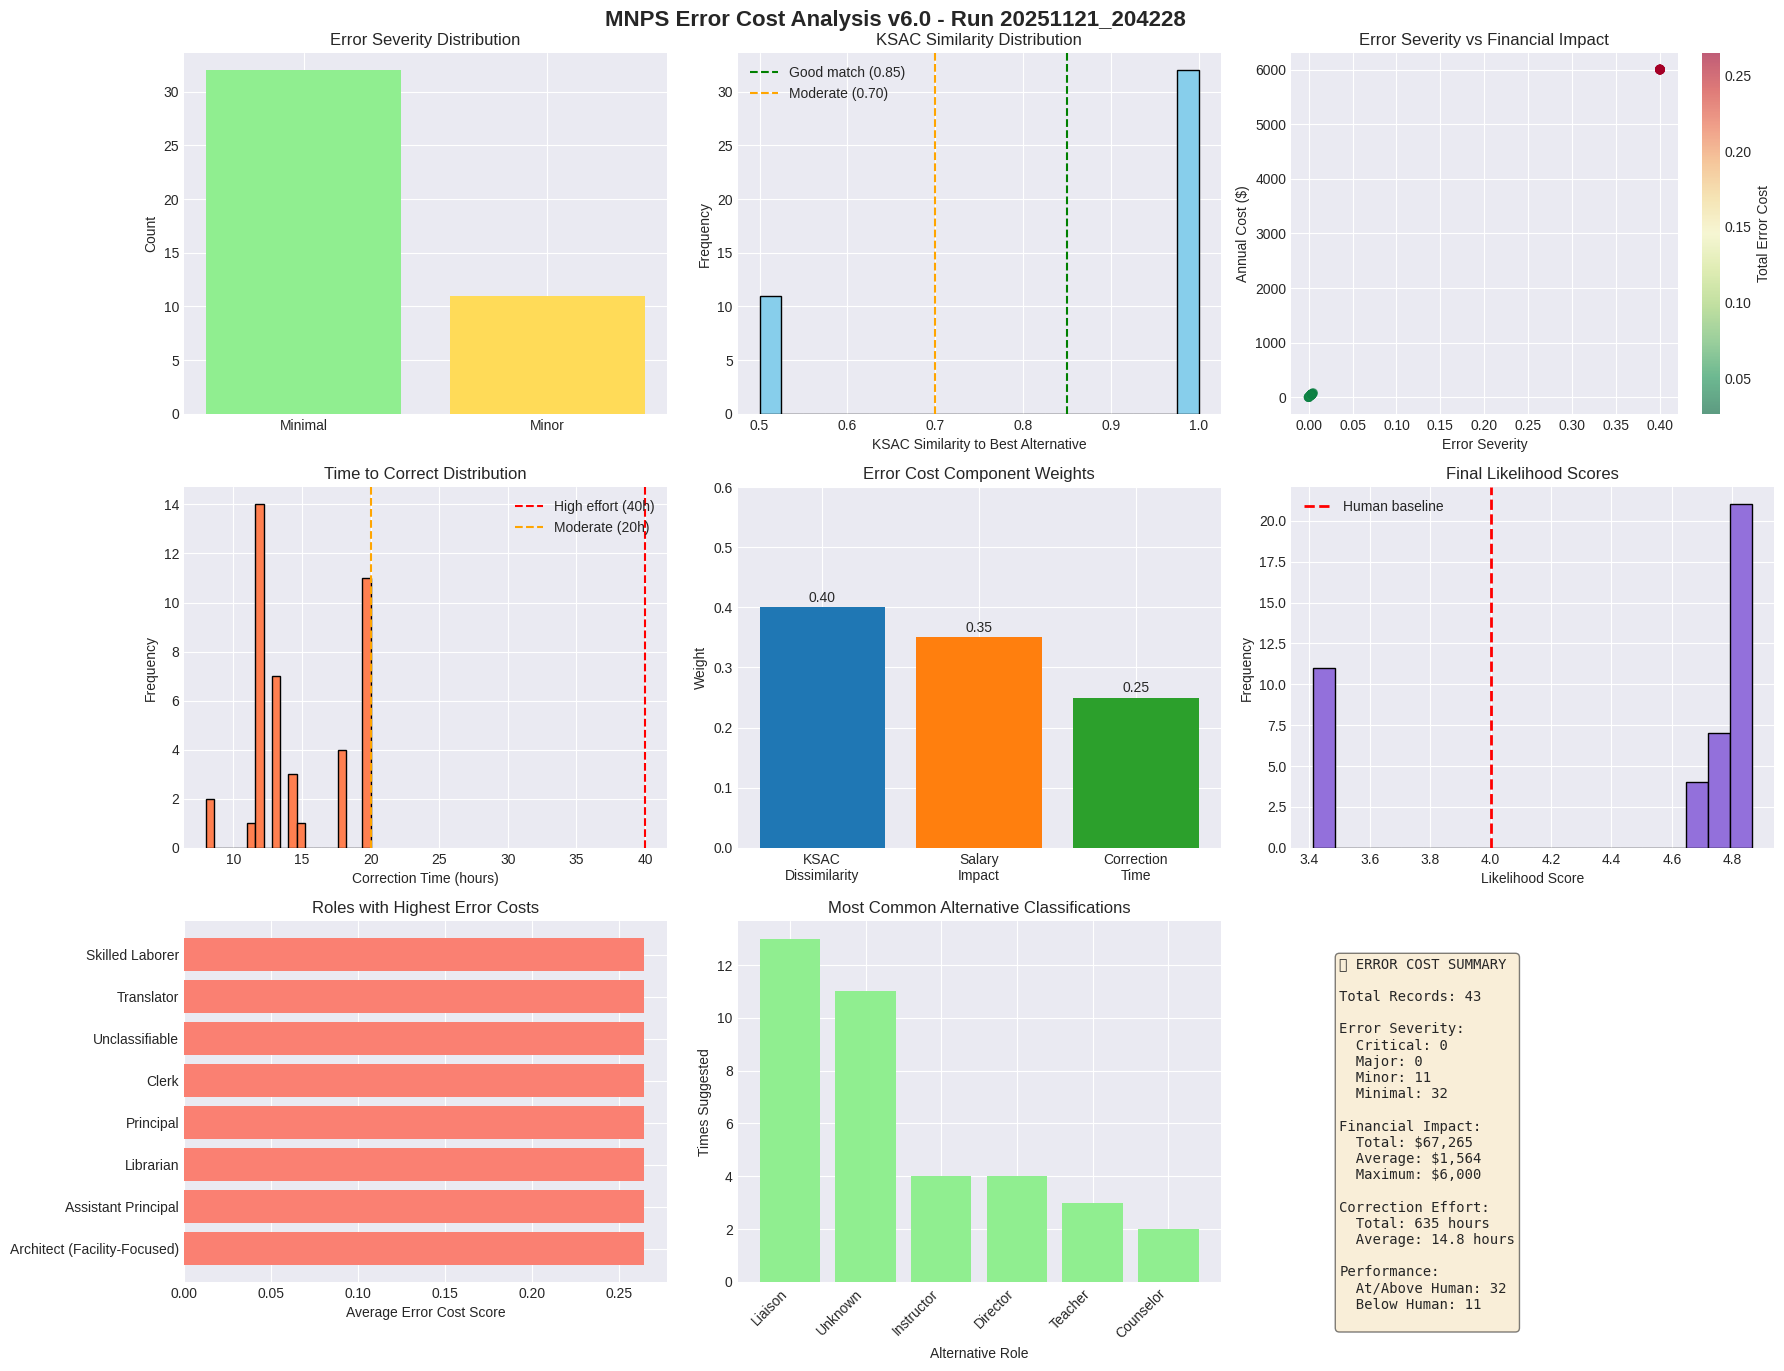

In [11]:
#@title 🔟 Generate Error Cost Visualizations { display-mode: "form" }

# Set up the plot
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle(f'MNPS Error Cost Analysis v6.0 - Run {timestamp}', fontsize=16, fontweight='bold')

# 1. Error Severity Distribution
ax = axes[0, 0]
severity_counts = results_df['severity_category'].value_counts()
colors = {'Critical': '#d62728', 'Major': '#ff7f0e', 'Minor': '#ffdb58', 'Minimal': '#90ee90'}
ax.bar(severity_counts.index, severity_counts.values,
       color=[colors.get(x, 'gray') for x in severity_counts.index])
ax.set_title('Error Severity Distribution')
ax.set_ylabel('Count')

# 2. KSAC Similarity Scores
ax = axes[0, 1]
ax.hist(results_df['ksac_best_similarity'], bins=20, color='skyblue', edgecolor='black')
ax.axvline(0.85, color='green', linestyle='--', label='Good match (0.85)')
ax.axvline(0.70, color='orange', linestyle='--', label='Moderate (0.70)')
ax.set_xlabel('KSAC Similarity to Best Alternative')
ax.set_ylabel('Frequency')
ax.set_title('KSAC Similarity Distribution')
ax.legend()

# 3. Financial Impact
ax = axes[0, 2]
ax.scatter(results_df['error_severity'], results_df['salary_cost_annual'],
           c=results_df['total_error_cost_score'], cmap='RdYlGn_r', alpha=0.6)
ax.set_xlabel('Error Severity')
ax.set_ylabel('Annual Cost ($)')
ax.set_title('Error Severity vs Financial Impact')
plt.colorbar(ax.collections[0], ax=ax, label='Total Error Cost')

# 4. Correction Time Distribution
ax = axes[1, 0]
ax.hist(results_df['correction_time_hours'], bins=20, color='coral', edgecolor='black')
ax.axvline(40, color='red', linestyle='--', label='High effort (40h)')
ax.axvline(20, color='orange', linestyle='--', label='Moderate (20h)')
ax.set_xlabel('Correction Time (hours)')
ax.set_ylabel('Frequency')
ax.set_title('Time to Correct Distribution')
ax.legend()

# 5. Error Cost Components
ax = axes[1, 1]
components = ['KSAC\nDissimilarity', 'Salary\nImpact', 'Correction\nTime']
weights = [KSAC_DISSIMILARITY_WEIGHT, SALARY_IMPACT_WEIGHT, CORRECTION_TIME_WEIGHT]
ax.bar(components, weights, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_ylabel('Weight')
ax.set_title('Error Cost Component Weights')
ax.set_ylim(0, 0.6)
for i, v in enumerate(weights):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center')

# 6. Likelihood Score Distribution
ax = axes[1, 2]
ax.hist(results_df['likelihood_score'], bins=20, color='mediumpurple', edgecolor='black')
ax.axvline(4.0, color='red', linestyle='--', linewidth=2, label='Human baseline')
ax.set_xlabel('Likelihood Score')
ax.set_ylabel('Frequency')
ax.set_title('Final Likelihood Scores')
ax.legend()

# 7. Top Error-Prone Roles
ax = axes[2, 0]
role_errors = results_df.groupby('classification')['total_error_cost_score'].mean().sort_values(ascending=False)[:8]
ax.barh(role_errors.index, role_errors.values, color='salmon')
ax.set_xlabel('Average Error Cost Score')
ax.set_title('Roles with Highest Error Costs')

# 8. KSAC Alternative Roles
ax = axes[2, 1]
# Count most common alternative suggestions
alternatives = results_df['ksac_best_alternative'].value_counts()[:6]
ax.bar(alternatives.index, alternatives.values, color='lightgreen')
ax.set_xlabel('Alternative Role')
ax.set_ylabel('Times Suggested')
ax.set_title('Most Common Alternative Classifications')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 9. Summary Statistics
ax = axes[2, 2]
ax.axis('off')
summary_text = f"""📊 ERROR COST SUMMARY

Total Records: {len(results_df)}

Error Severity:
  Critical: {len(results_df[results_df['severity_category'] == 'Critical'])}
  Major: {len(results_df[results_df['severity_category'] == 'Major'])}
  Minor: {len(results_df[results_df['severity_category'] == 'Minor'])}
  Minimal: {len(results_df[results_df['severity_category'] == 'Minimal'])}

Financial Impact:
  Total: ${results_df['salary_cost_annual'].sum():,.0f}
  Average: ${results_df['salary_cost_annual'].mean():,.0f}
  Maximum: ${results_df['salary_cost_annual'].max():,.0f}

Correction Effort:
  Total: {results_df['correction_time_hours'].sum():,.0f} hours
  Average: {results_df['correction_time_hours'].mean():.1f} hours

Performance:
  At/Above Human: {len(results_df[results_df['likelihood_score'] >= 4.0])}
  Below Human: {len(results_df[results_df['likelihood_score'] < 4.0])}
"""
ax.text(0.1, 0.9, summary_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
viz_path = os.path.join(run_results_path, 'error_cost_analysis_v6.png')
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Visualization saved to: {viz_path}")
plt.show()

In [12]:
#@title 1️⃣1️⃣ Save Results and Generate Reports { display-mode: "form" }

print("💾 Saving comprehensive error cost analysis results...\n")

# 1. Save main results
main_results_path = os.path.join(run_results_path, 'error_cost_analysis_v6.csv')
results_df.to_csv(main_results_path, index=False)
print(f"✅ Results saved to: {main_results_path}")

# 2. Save critical errors report
critical_errors = results_df[results_df['severity_category'] == 'Critical'].sort_values('total_error_cost_score', ascending=False)
if not critical_errors.empty:
    critical_path = os.path.join(run_results_path, 'critical_errors.csv')
    critical_errors.to_csv(critical_path, index=False)
    print(f"✅ Critical errors saved to: {critical_path}")

# 3. Generate executive summary report
report_path = os.path.join(run_results_path, 'executive_summary_v6.txt')
with open(report_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("MNPS ERROR COST ANALYSIS v6.0 - EXECUTIVE SUMMARY\n")
    f.write(f"Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("="*80 + "\n\n")

    f.write("KEY FINDINGS:\n")
    f.write(f"  • Total Annual Cost of Errors: ${results_df['salary_cost_annual'].sum():,.0f}\n")
    f.write(f"  • Total Correction Time Needed: {results_df['correction_time_hours'].sum():,.0f} hours\n")
    f.write(f"  • Critical Errors Requiring Immediate Action: {len(critical_errors)}\n")
    f.write(f"  • Classifications at/above Human Baseline: {len(results_df[results_df['likelihood_score'] >= 4.0])}\n")
    f.write("\n")

    f.write("ERROR SEVERITY BREAKDOWN:\n")
    for category in ['Critical', 'Major', 'Minor', 'Minimal']:
        subset = results_df[results_df['severity_category'] == category]
        if len(subset) > 0:
            f.write(f"  {category}: {len(subset)} cases\n")
            f.write(f"    - Average Cost: ${subset['salary_cost_annual'].mean():,.0f}\n")
            f.write(f"    - Average Time: {subset['correction_time_hours'].mean():.1f} hours\n")
    f.write("\n")

    f.write("TOP 10 MOST EXPENSIVE ERRORS:\n")
    top_10 = results_df.nlargest(10, 'salary_cost_annual')[['job_title', 'classification', 'salary_cost_annual', 'correction_time_hours', 'recommendations']]
    for idx, row in top_10.iterrows():
        f.write(f"  {idx+1}. {row['job_title']} → {row['classification']}\n")
        f.write(f"     Cost: ${row['salary_cost_annual']:,.0f} | Time: {row['correction_time_hours']:.1f}h\n")
        if row['recommendations']:
            f.write(f"     Action: {row['recommendations']}\n")
        f.write("\n")

    f.write("KSAC SIMILARITY INSIGHTS:\n")
    f.write(f"  • Average Similarity to Best Alternative: {results_df['ksac_best_similarity'].mean():.3f}\n")
    high_similarity = results_df[results_df['ksac_best_similarity'] > 0.85]
    f.write(f"  • Cases with Very Similar Alternatives (>0.85): {len(high_similarity)}\n")
    if len(high_similarity) > 0:
        f.write("    Common confusions:\n")
        confusions = high_similarity.groupby(['classification', 'ksac_best_alternative']).size().sort_values(ascending=False)[:5]
        for (orig, alt), count in confusions.items():
            f.write(f"      - {orig} ↔ {alt}: {count} cases\n")
    f.write("\n")

    f.write("RECOMMENDATIONS:\n")
    f.write("  1. IMMEDIATE ACTIONS:\n")
    f.write(f"     • Review {len(critical_errors)} critical errors (potential savings: ${critical_errors['salary_cost_annual'].sum():,.0f})\n")
    f.write(f"     • Focus on top 10 costly errors first (80/20 rule)\n")
    f.write("\n")

    f.write("  2. SYSTEMIC IMPROVEMENTS:\n")
    # Find most common problematic roles
    problem_roles = results_df[results_df['error_severity'] > MAJOR_ERROR_THRESHOLD].groupby('classification').size().sort_values(ascending=False)[:3]
    for role, count in problem_roles.items():
        f.write(f"     • Improve {role} classification criteria ({count} problematic cases)\n")
    f.write("\n")

    f.write("  3. TRAINING PRIORITIES:\n")
    # Find roles with high KSAC confusion
    confused_roles = results_df[results_df['ksac_best_similarity'] > 0.85].groupby('classification').size().sort_values(ascending=False)[:3]
    for role, count in confused_roles.items():
        alternatives = results_df[(results_df['classification'] == role) & (results_df['ksac_best_similarity'] > 0.85)]['ksac_best_alternative'].mode()
        if len(alternatives) > 0:
            f.write(f"     • Clarify distinction between {role} and {alternatives[0]}\n")
    f.write("\n")

    f.write("ESTIMATED ROI OF CORRECTIONS:\n")
    total_cost = results_df['salary_cost_annual'].sum()
    total_hours = results_df['correction_time_hours'].sum()
    cost_per_hour = 75  # Assume $75/hour for HR professional
    correction_investment = total_hours * cost_per_hour
    roi = (total_cost - correction_investment) / correction_investment * 100

    f.write(f"  • Total Error Cost: ${total_cost:,.0f}\n")
    f.write(f"  • Correction Investment: ${correction_investment:,.0f} ({total_hours:.0f} hours @ ${cost_per_hour}/hr)\n")
    f.write(f"  • Potential Savings: ${total_cost - correction_investment:,.0f}\n")
    f.write(f"  • ROI: {roi:.0f}%\n")

print(f"✅ Executive summary saved to: {report_path}")

print("\n" + "="*60)
print("🎯 ERROR COST ANALYSIS COMPLETE!")
print("="*60)
print(f"\nKey Metrics:")
print(f"  • Total Annual Cost of Errors: ${results_df['salary_cost_annual'].sum():,.0f}")
print(f"  • Critical Errors: {len(critical_errors)} requiring immediate review")
print(f"  • Total Correction Time: {results_df['correction_time_hours'].sum():,.0f} hours")
print(f"  • Potential ROI: {roi:.0f}% from fixing errors")
print(f"\nAll results saved to: {run_results_path}")

💾 Saving comprehensive error cost analysis results...

✅ Results saved to: /content/drive/MyDrive/MNPS_Likelihood_Analysis/Results/Run_v6_20251121_204228/error_cost_analysis_v6.csv
✅ Executive summary saved to: /content/drive/MyDrive/MNPS_Likelihood_Analysis/Results/Run_v6_20251121_204228/executive_summary_v6.txt

🎯 ERROR COST ANALYSIS COMPLETE!

Key Metrics:
  • Total Annual Cost of Errors: $67,265
  • Critical Errors: 0 requiring immediate review
  • Total Correction Time: 635 hours
  • Potential ROI: 41% from fixing errors

All results saved to: /content/drive/MyDrive/MNPS_Likelihood_Analysis/Results/Run_v6_20251121_204228
